# Steel Defect Detection — Kaggle Training
Training di Kaggle 2xT4 (30GB RAM, 2x15GB VRAM)

**Setup:**
1. Add Data → Severstal Steel Defect Detection competition dataset
2. Add Data → Source code (.py files) sebagai Dataset
3. Settings → Internet ON (pip install)

In [1]:
# Cell 1: Cek Environment
import torch, os
from pathlib import Path

print('Torch:', torch.__version__)
print('CUDA:', torch.cuda.is_available())
if torch.cuda.is_available():
    print(f'GPU count: {torch.cuda.device_count()}')
    for i in range(torch.cuda.device_count()):
        print(f'  GPU {i}: {torch.cuda.get_device_name(i)} ({torch.cuda.get_device_properties(i).total_memory / 1024**3:.1f} GB)')

import psutil
ram = psutil.virtual_memory()
print(f'RAM: {ram.total / 1024**3:.1f} GB total, {ram.available / 1024**3:.1f} GB available')

print(f'\n/kaggle/input contents:')
for entry in sorted(os.listdir('/kaggle/input')):
    full = Path('/kaggle/input') / entry
    if full.is_dir():
        print(f'  {entry}/')

Torch: 2.10.0+cu128
CUDA: True
GPU count: 2
  GPU 0: Tesla T4 (14.6 GB)
  GPU 1: Tesla T4 (14.6 GB)
RAM: 31.4 GB total, 29.9 GB available

/kaggle/input contents:
  competitions/


In [2]:
# Cell 2: Install dependencies
print('Installing...')
!pip install segmentation-models-pytorch timm albumentations scikit-learn 2>&1 | tail -3
print('Done')

Installing...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 3.8 MB/s eta 0:00:00
Done


In [3]:
# Cell 3: Clone source code dari GitHub ke /kaggle/working/
import subprocess, sys, shutil
from pathlib import Path

REPO_URL = 'https://github.com/kurob1993/steel-defect-detection-efficientnet.git'
CLONE_DIR = Path('/kaggle/working/repo')

if not CLONE_DIR.exists():
    print(f'Cloning {REPO_URL} ...')
    result = subprocess.run(
        ['git', 'clone', '--depth', '1', REPO_URL, str(CLONE_DIR)],
        capture_output=True, text=True
    )
    if result.returncode != 0:
        print(result.stderr)
        raise RuntimeError('git clone failed')
    print('Clone done')
else:
    print('Repo already cloned, pulling latest...')
    result = subprocess.run(['git', '-C', str(CLONE_DIR), 'pull'], capture_output=True, text=True)
    if result.returncode == 0:
        print(result.stdout)
    else:
        print('Error:', result.stderr)

# Copy .py files ke /kaggle/working/
copied_files = []
for py in CLONE_DIR.glob('*.py'):
    shutil.copy2(py, '/kaggle/working/')
    copied_files.append(py.name)

print(f'Files copied: {sorted(copied_files)}')


Cloning https://github.com/kurob1993/steel-defect-detection-efficientnet.git ...
Clone done
Files copied: ['dataset.py', 'export_onnx.py', 'losses.py', 'model.py', 'predict_test.py', 'train.py', 'train_config.py', 'tta.py']


In [4]:
# Cell 4: Copy dataset ke /kaggle/working/data/ untuk I/O cepat
# /kaggle/input sangat lambat untuk baca gambar!
# Ini langkah PALING PENTING untuk speed training

COMPETITION_DIR = Path('/kaggle/input/competitions/severstal-steel-defect-detection')
LOCAL_DATA = Path('/kaggle/working/data')

# Cari dataset
if not (COMPETITION_DIR / 'train.csv').exists():
    for csv in Path('/kaggle/input').glob('**/train.csv'):
        if (csv.parent / 'train_images').exists():
            COMPETITION_DIR = csv.parent
            break

print(f'Dataset source: {COMPETITION_DIR}')

# Copy train.csv
if not (LOCAL_DATA / 'train.csv').exists():
    LOCAL_DATA.mkdir(parents=True, exist_ok=True)
    shutil.copy2(COMPETITION_DIR / 'train.csv', LOCAL_DATA / 'train.csv')
    print('train.csv copied')

# Copy train_images ke local storage (PALING PENTING)
if not (LOCAL_DATA / 'train_images').exists():
    print('Copying train_images ke /kaggle/working/data/ (ini memakan ~3-5 menit tapi hanya sekali)...')
    shutil.copytree(COMPETITION_DIR / 'train_images', LOCAL_DATA / 'train_images')
    print('Done!')

# Copy test_images kalau ada
if (COMPETITION_DIR / 'test_images').exists() and not (LOCAL_DATA / 'test_images').exists():
    shutil.copytree(COMPETITION_DIR / 'test_images', LOCAL_DATA / 'test_images')
    print('test_images copied')

# Verify
print(f'\nLocal data:')
print(f'  train.csv:     {(LOCAL_DATA / "train.csv").exists()}')
print(f'  train_images:  {(LOCAL_DATA / "train_images").exists()} ({len(list((LOCAL_DATA / "train_images").glob("*.jpg")))} files)')
print(f'  test_images:   {(LOCAL_DATA / "test_images").exists()}')

Dataset source: /kaggle/input/competitions/severstal-steel-defect-detection
train.csv copied
Copying train_images ke /kaggle/working/data/ (ini memakan ~3-5 menit tapi hanya sekali)...
Done!
test_images copied

Local data:
  train.csv:     True
  train_images:  True (12568 files)
  test_images:   True


In [5]:
# Cell 5: Set environment + verify
import sys, os
import torch
from pathlib import Path

os.environ['DATA_DIR'] = '/kaggle/working/data'
os.environ['MODEL_SAVE_DIR'] = '/kaggle/working/models/segmentation'
os.environ['NUM_WORKERS'] = '4'  # Total worker budget; train.py akan split jadi 2/proses saat DDP 2 GPU
os.environ['USE_RAM_CACHE'] = 'true'  # Single GPU: RAM cache ON. DDP: auto disable supaya cache tidak dobel.

sys.path.insert(0, '/kaggle/working')

from train_config import (
    DATA_DIR, TRAIN_CSV, TRAIN_IMG_DIR, MODEL_SAVE_DIR,
    BEST_MODEL_PATH, BATCH_SIZE, ACCUMULATE_STEPS, USE_RAM_CACHE, USE_FP16
)

print(f'DATA_DIR       = {DATA_DIR}')
print(f'TRAIN_CSV      = {TRAIN_CSV} ({TRAIN_CSV.exists()})')
print(f'TRAIN_IMG_DIR  = {TRAIN_IMG_DIR} ({TRAIN_IMG_DIR.exists()})')
print(f'BATCH_SIZE     = {BATCH_SIZE}')
print(f'ACCUMULATE     = {ACCUMULATE_STEPS}')
print(f'EFFECTIVE BATCH= {BATCH_SIZE * ACCUMULATE_STEPS}')
print(f'USE_RAM_CACHE  = {USE_RAM_CACHE}')
print(f'USE_FP16       = {USE_FP16}')
print(f'GPU count      = {torch.cuda.device_count()}')
print(f'NUM_WORKERS    = {os.getenv("NUM_WORKERS")}')


DATA_DIR       = /kaggle/working/data
TRAIN_CSV      = /kaggle/working/data/train.csv (True)
TRAIN_IMG_DIR  = /kaggle/working/data/train_images (True)
BATCH_SIZE     = 8
ACCUMULATE     = 2
EFFECTIVE BATCH= 16
USE_RAM_CACHE  = True
USE_FP16       = True
GPU count      = 2
NUM_WORKERS    = 4


In [6]:
# Cell 6: TRAIN with real 2-GPU DDP
# Target score lebih tinggi: train lebih lama + early stopping lebih sabar.

num_gpus = torch.cuda.device_count()
batch = 16 if num_gpus >= 2 else 8

os.environ['OMP_NUM_THREADS'] = '1'
os.environ['MKL_NUM_THREADS'] = '1'

print(f'GPU: {num_gpus}, Global Batch: {batch}')
print('=' * 60)

%cd /kaggle/working
if num_gpus >= 2:
    print('Mode: DDP 2-GPU (torch.distributed.run)')
    print(f'Command: python -m torch.distributed.run --standalone --nproc_per_node=2 train.py --epochs 80 --batch-size {batch} --early-stop-patience 20 --min-epochs 20')
    !python -m torch.distributed.run --standalone --nproc_per_node=2 train.py --epochs 80 --batch-size {batch} --early-stop-patience 20 --min-epochs 20
else:
    print('Mode: Single GPU')
    print(f'Command: python train.py --epochs 80 --batch-size {batch} --device cuda --early-stop-patience 20 --min-epochs 20')
    !python train.py --epochs 80 --batch-size {batch} --device cuda --early-stop-patience 20 --min-epochs 20


GPU: 2, Global Batch: 16
/kaggle/working
Mode: DDP 2-GPU (torch.distributed.run)
Command: python -m torch.distributed.run --standalone --nproc_per_node=2 train.py --epochs 80 --batch-size 16 --early-stop-patience 20 --min-epochs 20
[W526 16:55:33.130844488 socket.cpp:207] [c10d] The hostname of the client socket cannot be retrieved. err=-3
[W526 16:55:48.172269849 socket.cpp:207] [c10d] The hostname of the client socket cannot be retrieved. err=-3
[W526 16:55:48.173077232 socket.cpp:207] [c10d] The hostname of the client socket cannot be retrieved. err=-3
Device: cuda:0
  GPU 0: Tesla T4 (14.6 GB)
  GPU 1: Tesla T4 (14.6 GB)
Multi-GPU: ✅ DDP x2
FP16: ✅ Ya

📦 Loading dataset...
   Train: 10054 gambar
   Val:   2514 gambar
   ⚠️  RAM cache dimatikan di DDP agar tidak menduplikasi ~11GB cache per proses
   DDP batch: global 16 → 8/GPU × 2 proses
   DataLoader workers: total 4 → 2/proses

🔧 Building Two-Headed Network
   Encoder:  efficientnet-b3
   Decoder:  FPN
   Input:    1ch × 256×800

In [7]:
# Cell 7: Training history
import json
history_path = Path('/kaggle/working/models/segmentation/training_history.json')
if history_path.exists():
    h = json.loads(history_path.read_text())
    print(f'Epochs: {len(h)}')
    best = max(h, key=lambda x: x['val_mean_dice'])
    print(f'Best Dice: {best["val_mean_dice"]:.4f} (epoch {best["epoch"]})')
else:
    print('No history yet')

Epochs: 80
Best Dice: 0.8216 (epoch 65)


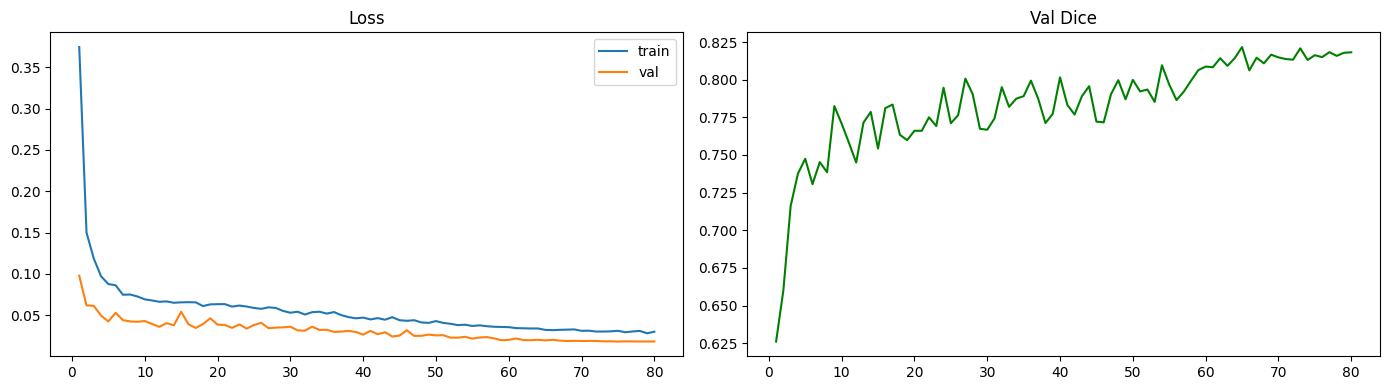

In [8]:
# Cell 8: Plot curves
import matplotlib.pyplot as plt

history_path = Path('/kaggle/working/models/segmentation/training_history.json')
if history_path.exists():
    h = json.loads(history_path.read_text())
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
    ax1.plot([x['epoch'] for x in h], [x['train_loss'] for x in h], label='train')
    ax1.plot([x['epoch'] for x in h], [x['val_loss'] for x in h], label='val')
    ax1.legend(); ax1.set_title('Loss')
    ax2.plot([x['epoch'] for x in h], [x['val_mean_dice'] for x in h], color='green')
    ax2.set_title('Val Dice')
    plt.tight_layout()
    plt.savefig('/kaggle/working/training_curves.png', dpi=150)
    plt.show()

In [9]:
# Cell 9: Export + Zip
!python export_onnx.py --model /kaggle/working/models/segmentation/fpn_efficientnet_b3_best.pth --output /kaggle/working/models/segmentation/fpn_efficientnet_b3.onnx 2>/dev/null || true
!cd /kaggle/working && zip -r steel_model_outputs.zip models/ outputs/ training_curves.png 2>/dev/null || true
!ls -lah /kaggle/working/steel_model_outputs.zip
!ls -lah /kaggle/working/models/segmentation/

Loading model: /kaggle/working/models/segmentation/fpn_efficientnet_b3_best.pth
Exporting ONNX → /kaggle/working/models/segmentation/fpn_efficientnet_b3.onnx
	zip warning: name not matched: outputs/
  adding: models/ (stored 0%)
  adding: models/segmentation/ (stored 0%)
  adding: models/segmentation/fpn_efficientnet_b3_best.pth (deflated 32%)
  adding: models/segmentation/training_history.json (deflated 75%)
  adding: models/segmentation/fpn_efficientnet_b3_last.pth (deflated 34%)
  adding: training_curves.png (deflated 10%)
-rw-r--r-- 1 root root 189M May 26 21:03 /kaggle/working/steel_model_outputs.zip
total 281M
drwxr-xr-x 2 root root 4.0K May 26 17:00 .
drwxr-xr-x 3 root root 4.0K May 26 16:55 ..
-rw-r--r-- 1 root root 141M May 26 20:16 fpn_efficientnet_b3_best.pth
-rw-r--r-- 1 root root 141M May 26 21:02 fpn_efficientnet_b3_last.pth
-rw-r--r-- 1 root root  16K May 26 21:02 training_history.json
